# Cross-Border E-Commerce Agent


### Overview
This project automates the process of marketing global products into specific countries and cultures, it is made up of several agents, each agent has a specific job.

### Agents
`Note: Each Agent has its own subgraph`
1. General Agents
2. Specific Agents


#### General Agents
1. `Resources Agent:` deals with URLs, text files, Images, CSV, Json, it fetches data from these different resources

2. `Summary Agent:` given a large extracted text, it aims to write a short summary about that text via splitting that text into chunks, and processing each individually, producing a mini-summary per each chunk, then at the end all of these chunks are aggregated into a single summary, in this way the agent is able to parallise the process of summarising which makes it run faster and uses less tokens

3. `Translation Agent:` given a text, it checks if its in target language or not, if it is not, it translates it into target language

4. `Currency Exchange Agent:` given prices of products in a different currency than the target currency, it changes the price into target currency

5. `Vector Database Agent:` saves output produced by agent in a local vectorised database using embedding model

6. `SQL Agent:` saves products list into database, also it can fetch them back if requested
#### Specific Agents
1. `Products Agent:` 
    - uses `Resources Agent` to fetch data
    - uses `Translation Agent:` to translate data if needed
    - uses data to extract product list
    - uses `SQL Agent` to save
2. `Latest News Agent:`
    - uses `Resources Agent` to fetch data
    - uses `Translation Agent` to translate data if needed
    - uses `Summary Agent` to summarise data into 10 bullet points
    - uses `Vector Database Agent` to save the summary
3. `Culture Agent:`
    - uses `Resources Agent` to fetch data
    - uses `Translation Agent` to translate data if needed
    - uses `Summary Agent` to summarise data into a short summary about the country's culture
    - uses `Vector Database Agent` to save the summary
4. `Product Classifier Agent:`
    - uses `SQL Agent` to fetch products list
    - uses `Vector Database Agent` to fetch `Latest News Agent` and `Culture Agent` documents
    - classifies most top 5 appropriate candidate products for marketing in the target country
    - writes a summary about each product and why it should be marketed and how should it be marketed in the target nation
    - uses `SQL Agent` to save the top candidates
    - uses `Vector Database Agent` to save the summary
5. `Marketing Agent:`
    - uses `Vector Database Agent` to fetch `Product Classifier Agent` documents
    - uses `SQL Agent` to fetch top candidate products list to ensure the model does not hallucinate and make numbers for these products
    - writes general no-platform specific script
    - uses `Vector Database Agent` to save the script
6. `Commerical Law Agent:`
    - uses `Resources Agent` to fetch data
    - uses `Translation Agent:` to translate data if needed
    - uses `Summary Agent` to rapidly check if script generated by `Marketing Agent` Matches the commerical law documents
    - if script does not match commerical law, it modifies it until it matches it
    - uses `Vector Database Agent` to save the script

7. `Platform Specific Agent:`
    - uses `Resources Agent` to fetch data
    - uses `Vector Database Agent` to fetch the general script from `Marketing Agent`
    - writes platform-specific script
    - uses `Vector Database Agent` to save all the platform-specific scripts
    

<br>

# Intialisation

In [2]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional, Dict, Any
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
import operator
from requests import request
from bs4 import BeautifulSoup
from html_to_markdown import convert
import time
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import csv

load_dotenv()
FAIL="failed"
SUCCESS="success"

## LLM

In [3]:
general_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

## Utility Functions

In [4]:
from utility_functions.general_functions import handle_web_requests, get_encoding, locate_file

# General Agents
### Resources Agent

#### Resource State

In [5]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional, Dict, Any
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
import operator

class ResourceWorkerState(TypedDict): #private state
    current_resource: str
    type_resource: Literal["json_file","html","api","txt","csv"]
    messages: Annotated[list[str], add_messages]
    data_list : Annotated[list[str], add_messages]
    error_messages : Annotated[list[str], add_messages]
    processed_resource_list: Annotated[list[str], operator.add]



class ResourceState(TypedDict):
    messages: Annotated[list[str], add_messages]
    data_list : Annotated[list[str], add_messages]
    resource_list : list[str] 
    processed_resource_list: Annotated[list[str], operator.add]
    error_messages : Annotated[list[str], add_messages]
    feedback_message : str

#### Pydantic Models

In [63]:
#https://docs.langchain.com/oss/python/langgraph/graph-api

class ResourceExtractSchema(BaseModel):
    """runs once, it intialises resource_list"""
    resource_list : list[str] = Field(description="given a message extract urls and datasets csv/txt/json filenames from that message and store them in list")

class ResourceProcessingSchema(BaseModel):
    """changes throughout nodes"""
    type_resource: Literal["json_file","html","txt","api","csv"] = Field(description="Based on resource if it has api word in it assume it returns 'api' , if it is a normal webpage assume it returns 'html' , else check its file extension type and select appropriate data type'")

#### Classifier Nodes

In [64]:


def manager_task_classifier(state: ResourceState):
    """given a list of resources, and list of processed resources, it checks if they are equal then terminates,
    however if an error took place it will retry to fetch it again, if it failed again it will write error message explaining
    what happened then it will exit"""
    
    print("manager_task_classifier() --> Analysis --->")
    print("============================================")
    print("len: processed_resource_list",len(state["processed_resource_list"]))
    print("len: resource_list",len(state["resource_list"]))
    print("resource_list ",state["resource_list"])
    print("processed_resource_list ",state["processed_resource_list"])
    print("current_resource ",state["current_resource"])
    print("============================================")

    if len(state["processed_resource_list"]) == len(state["resource_list"]):
        work_status = "finished"
    else:
        work_status = "inprogress"

    return {"work_status":work_status}

#### Router Nodes

In [6]:
from langgraph.types import Send

def resource_router(state: ResourceWorkerState):
    return state["type_resource"]

def resource_task_splitter_router(state: ResourceState):
    return [Send("resource_subgraph",{"current_resource":resource}) for resource in state["resource_list"]]

def task_manager_router(state: ResourceState):
    return state["work_status"]

#### Nodes

In [66]:
def extract_resources(state: ResourceState):
    """given user message, it extracts all urls,txt file names, etc , also it returns data type for each url in a list"""
    last_message = state["messages"][-1].content
    structured_output_llm = general_llm.with_structured_output(ResourceExtractSchema)
    msg = [
        {"role":"user","content":last_message}
    ]
    result = structured_output_llm.invoke(msg)
    print("extract_resources --> resource_list",result.resource_list)
    return {"resource_list":result.resource_list}

def classify_resource(state: ResourceWorkerState):
    """given a resoruce, it will determine its data type"""
    current_resource = state["current_resource"]
    print("classify_resource  current_resource-->",current_resource)
    structured_output_llm = general_llm.with_structured_output(ResourceProcessingSchema)
    msg = [
        {"role":"user","content":current_resource}
    ]
    result = structured_output_llm.invoke(msg)
    return {"type_resource":result.type_resource}

def fetch_api(state: ResourceWorkerState):
    """given a current url resource, it extracts data from that resource, which will be generally in json"""
    print("state is",state)
    print("state is",type(state))

    current_resource = state["current_resource"]
    response, status_flag = handle_web_requests(current_resource)
    try:
        if status_flag == SUCCESS:
            return {"data_list":[str(response.json())], "processed_resource_list":[current_resource]}
        else:
            return {"error_messages":response}
    except Exception as e:
        return {"error_messages":f"error failed to fetch_api from {current_resource} reason {e}"}

def fetch_html(state: ResourceWorkerState):
    """given a current url resource that is not an api, it will be assumed that we want to web scrape it"""
    current_resource = state["current_resource"]
    response, status_flag = handle_web_requests(current_resource)
    try:
        if status_flag == SUCCESS:
            exclude_tags=["script","head","title","style","svg","!doctype","meta"]
            soup =  BeautifulSoup(response.text, "html.parser")
            for tag in exclude_tags:
                    for match in soup.find_all(tag):
                        match.extract()
            return {"messages":[str(soup)], "processed_resource_list":[current_resource]}
        else:
            return {"error_messages":response}
    except Exception as e:
        return {"error_messages":f"error failed to fetch html data from {current_resource} reason {e}"}

def html_to_markdown(state: ResourceWorkerState):
    """given html it will convert it into markdown which is the format most LLMs prefer for processing data"""
    print("html_to_markdown state --> ",state)
    html_content = state["messages"][-1].content
    markdown_object = convert(str(html_content))
    markdown = markdown_object.content
    return {"data_list":[markdown]}

def fetch_csv(state: ResourceWorkerState):
    """given a valid csv file name, it will be fetch csv data from it"""
    file_path_string = state["current_resource"]
    filepath = locate_file(file_path_string)
    correct_encoding = get_encoding(filepath)
    with open(filepath,mode="r", encoding=correct_encoding) as file:
        reader = csv.DictReader(file,delimiter=",")
        data = list(reader)
        return {"data_list":data, "processed_resource_list":[file_path_string]}

def fetch_txt(state: ResourceWorkerState):
    """given a valid txt file name, it will be fetch text data from it"""
    file_path_string = state["current_resource"]
    filepath = locate_file(file_path_string)
    correct_encoding = get_encoding(filepath)
    with open(filepath,mode="r", encoding=correct_encoding) as file:
        data = file.read()
        return {"data_list":[data], "processed_url_list":[file_path_string]}

def fetch_json_file(state: ResourceWorkerState):
    """given a valid json file, it will fetch json data from it"""
    file_path_string = state["current_resource"]
    filepath = locate_file(file_path_string)
    correct_encoding = get_encoding(filepath)
    with open(filepath,mode="r", encoding=correct_encoding) as file:
        data = file.read()
        return {"data_list":[data], "processed_url_list":[file_path_string]}


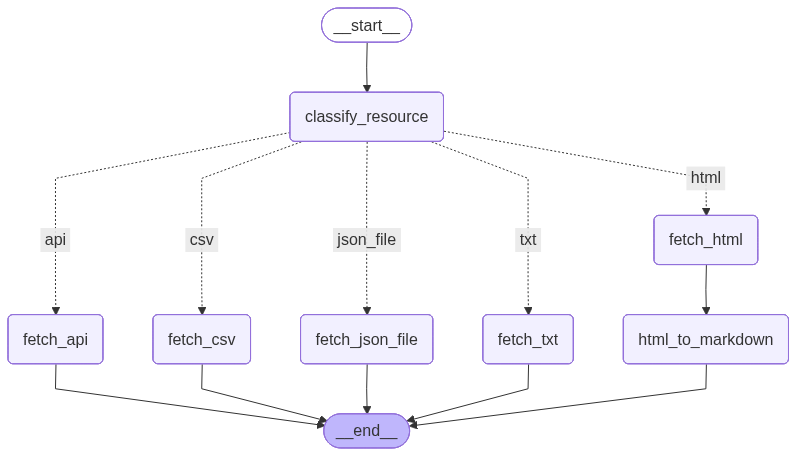

In [67]:
resource_subgraph = StateGraph(ResourceWorkerState)
resource_subgraph.add_node("fetch_api",fetch_api)
resource_subgraph.add_node("fetch_html",fetch_html)
resource_subgraph.add_node("html_to_markdown",html_to_markdown)
resource_subgraph.add_node("fetch_csv",fetch_csv)
resource_subgraph.add_node("fetch_txt",fetch_txt)
resource_subgraph.add_node("fetch_json_file",fetch_json_file)
resource_subgraph.add_node("classify_resource",classify_resource)
########################################################################
resource_subgraph.add_edge(START,"classify_resource")
resource_subgraph.add_conditional_edges("classify_resource",
                            resource_router,
                            {"api":"fetch_api",
                             "html":"fetch_html",
                             "txt":"fetch_txt",
                             "csv":"fetch_csv",
                             "json_file":"fetch_json_file"}
                            )
resource_subgraph.add_edge("fetch_html","html_to_markdown")
resource_subgraph.add_edge("html_to_markdown",END)
resource_subgraph.add_edge("fetch_json_file",END)
resource_subgraph.add_edge("fetch_txt",END)
resource_subgraph.add_edge("fetch_csv",END)
resource_subgraph.add_edge("fetch_api",END)

compiled_resource_subgraph= resource_subgraph.compile()

display(Image(compiled_resource_subgraph.get_graph().draw_mermaid_png()))

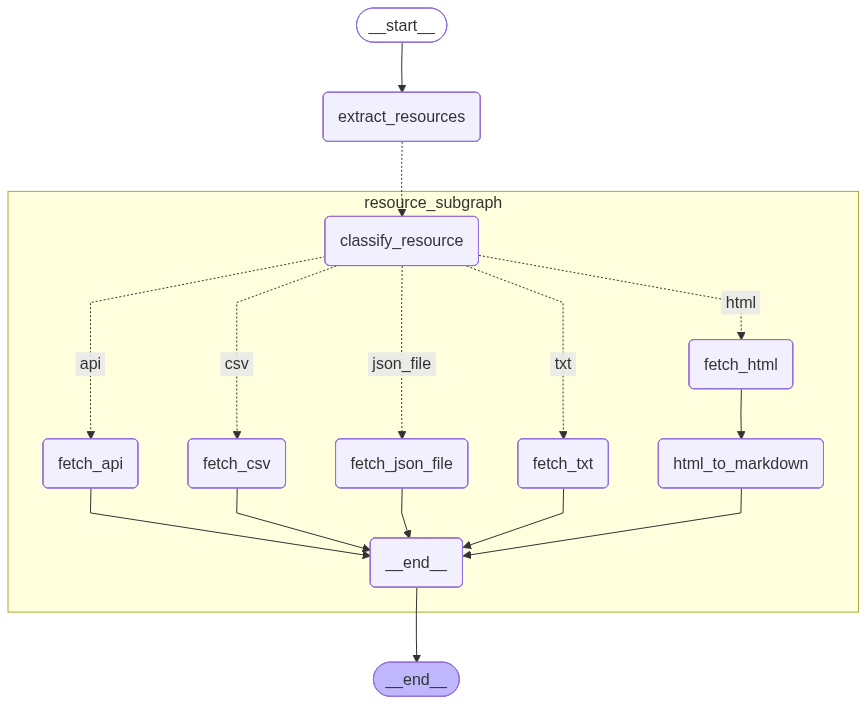

In [68]:
resource_parentgraph = StateGraph(ResourceState)
resource_parentgraph.add_node("extract_resources",extract_resources)
resource_parentgraph.add_node("resource_subgraph",compiled_resource_subgraph)
resource_parentgraph.add_edge(START,"extract_resources")
resource_parentgraph.add_conditional_edges("extract_resources",resource_task_splitter_router,["resource_subgraph"])
resource_parentgraph.add_edge("resource_subgraph",END)

compiled_resource_parentgraph = resource_parentgraph.compile()
display(Image(compiled_resource_parentgraph.get_graph(xray=True).draw_mermaid_png()))

In [69]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list, also extract data from this local file product_intelligence_report_v2.txt and datasets/mock_products_100.json"
        }
    ]
}
result = compiled_resource_parentgraph.invoke(
inputs
)

extract_resources --> resource_list ['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products', 'product_intelligence_report_v2.txt', 'datasets/mock_products_100.json']
classify_resource  current_resource--> http://books.toscrape.com/
classify_resource  current_resource--> https://api.escuelajs.co/api/v1/products
classify_resource  current_resource--> product_intelligence_report_v2.txt
classify_resource  current_resource--> datasets/mock_products_100.json
state is {'current_resource': 'https://api.escuelajs.co/api/v1/products', 'type_resource': 'api', 'messages': [], 'data_list': [], 'error_messages': [], 'processed_resource_list': []}
state is <class 'dict'>
html_to_markdown state -->  {'current_resource': 'http://books.toscrape.com/', 'type_resource': 'html', 'messages': [HumanMessage(content='<!DOCTYPE html>\n\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie

In [70]:
result["data_list"]

[HumanMessage(content='[Books to Scrape](index.html) We love being scraped!\n\n- [Home](index.html)\n- All products\n\n# All products\n\n**Warning!** This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.\n\n1.\n\n[![A Light in the Attic](media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg)](catalogue/a-light-in-the-attic_1000/index.html)\n\n  \n\n### [A Light in the ...](catalogue/a-light-in-the-attic_1000/index.html "A Light in the Attic")\n      Â£51.77\n\n     In stock\n\n2.\n\n[![Tipping the Velvet](media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg)](catalogue/tipping-the-velvet_999/index.html)\n\n  \n\n### [Tipping the Velvet](catalogue/tipping-the-velvet_999/index.html "Tipping the Velvet")\n      Â£53.74\n\n     In stock\n\n3.\n\n[![Soumission](media/cache/3e/ef/3eef99c9d9adef34639f510662022830.jpg)](catalogue/soumission_998/index.html)\n\n  \n\n### [Soumission](catalogue/soumission_998/index.html "Soum

In [71]:
result

{'messages': [HumanMessage(content='Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list, also extract data from this local file product_intelligence_report_v2.txt and datasets/mock_products_100.json', additional_kwargs={}, response_metadata={}, id='c091a9a6-6a4b-41ed-b291-a0a2e3bd8ad2'),
  HumanMessage(content='<!DOCTYPE html>\n\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->\n\n<body class="default" id="default">\n<header class="header container-fluid">\n<div class="page_inner">\n<div class="row">\n<div class="col-sm-8 h1"><a href="index.html">Books to Scrape</a><sm

In [72]:
result["processed_resource_list"]

['http://books.toscrape.com/', 'https://api.escuelajs.co/api/v1/products']

### Summary Agent

#### Summary State

In [ ]:
from langchain_core.documents import Document

class SummaryState(TypedDict):
    string_documents: list[str]
    documents: list[Document]
    splitted_documents: list[Document]
    error_messages: Annotated[list,add_messages]
    mini_summaries: Annotated[list[str], operator.add]
    final_summary: str

class SummaryWorkerState(TypedDict):
    current_clean_document: Document
    mini_summaries: Annotated[list[str], operator.add]
    final_summary: str

#### Pydantic Models

In [ ]:
class SummaryProcessingSchema(BaseModel):
    """changes throughout nodes"""
    current_mini_summary = Field(description="write a short summary regarding the current document you receive as input")

class SummaryOutputSchema(BaseModel):
    """changes throughout nodes"""
    final_summary = Field(description="write a final summary using all the mini-summaries you receive as input" \
    "make sure to make it cohesive")

#### Classifier Nodes

#### Router Nodes

In [ ]:
from langgraph.types import Send


def summary_task_splitter_router(state: SummaryState):
    """creates a summary subgraph for each splitted clean document privately"""
    return [Send("summary_subgraph", {"current_clean_document":current_clean_document}) for current_clean_document in state["current_clean_document"]]


#### Nodes

In [21]:
from langchain_text_splitters import CharacterTextSplitter

CHUNK_SIZE = 500
CHUNK_OVERLAP_SIZE = 50

text_splitter = CharacterTextSplitter.from_tiktoken_encoder(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP_SIZE)

In [ ]:

def string_to_documents(state: SummaryState):
    """converts string into documents data type"""
    documents=[]
    string_documents = state["string_documents"]
    for string_doc in string_documents:
        documents.append(Document(page_content=string_doc))
    return {"documents":documents}

def clean_documents(state: SummaryState):
    """given a list of documents, this function cleans them via removing 
    -binary data, 
    -images, 
    -excessive whitespaces
    -Raw HTML/XML
    -Legal Disclaimer
    """
    pass

def split_documents(state: SummaryState):
    """
    given a list of documents or a big large document with huge text, it splits into smaller documents that can be fed into llm workers
    """
    documents = state["documents"]
    splitted_documents = text_splitter.split_documents(documents)
    return {"split_documents":splitted_documents}

def summarise_document(state: SummaryWorkerState):
    """given a single document, a summary will be written, it will be considered as a mini-summary"""
    current_clean_document = state["current_clean_document"]
    summary_llm = general_llm.with_structured_output(SummaryProcessingSchema)
    msg = [
        {"role":"system","content":"given this document, summarise it"},
        {"role":"user","content":current_clean_document}
    ]
    result = summary_llm.invoke(msg)
    return {"mini_summaries":result.current_mini_summary}

def aggregrate_summaries(state: SummaryState):
    """combine all mini-summaries produced by all workers into a single summary"""
    mini_summaries = state["mini_summaries"]
    summary_llm = general_llm.with_structured_output(SummaryProcessingSchema)
    msg = [
        {"role":"system","content":"given all these summaries of documents, combine them into a single summary, "
        "refine it and make sure it is cohesive"},
        {"role":"user","content":mini_summaries}
    ]
    result = summary_llm.invoke(msg)
    return {"final_summary":result.final_summary}

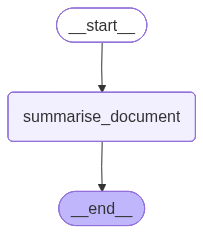

In [19]:
summary_subgraph = StateGraph(SummaryWorkerState)
summary_subgraph.add_node("summarise_document",summarise_document)
###########################################################################
summary_subgraph.add_edge(START,"summarise_document")
summary_subgraph.add_edge("summarise_document",END)
summary_subgraph_compiled = summary_subgraph.compile()
display(Image(summary_subgraph_compiled.get_graph().draw_mermaid_png()))

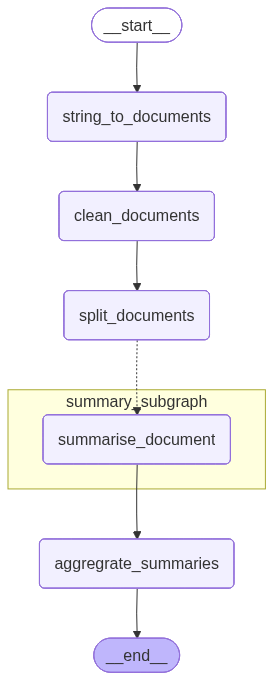

In [20]:
summary_parentgraph = StateGraph(SummaryWorkerState)
summary_parentgraph.add_node("clean_documents",clean_documents)
summary_parentgraph.add_node("string_to_documents",string_to_documents)
summary_parentgraph.add_node("split_documents",split_documents)
summary_parentgraph.add_node("summary_subgraph",summary_subgraph_compiled)
summary_parentgraph.add_node("aggregrate_summaries",aggregrate_summaries)
###########################################################################
summary_parentgraph.add_edge(START,"string_to_documents")
summary_parentgraph.add_edge("string_to_documents","clean_documents")
summary_parentgraph.add_edge("clean_documents","split_documents")
summary_parentgraph.add_conditional_edges("split_documents",summary_task_splitter_router,["summary_subgraph"])
summary_parentgraph.add_edge("summary_subgraph","aggregrate_summaries")
summary_parentgraph.add_edge("aggregrate_summaries",END)
summary_parentgraph = summary_parentgraph.compile()
display(Image(summary_parentgraph.get_graph(xray=True).draw_mermaid_png()))